# Parte 1 - Jerárquico Aglomerativo: Distancia Euclidiana y Enlace Simple

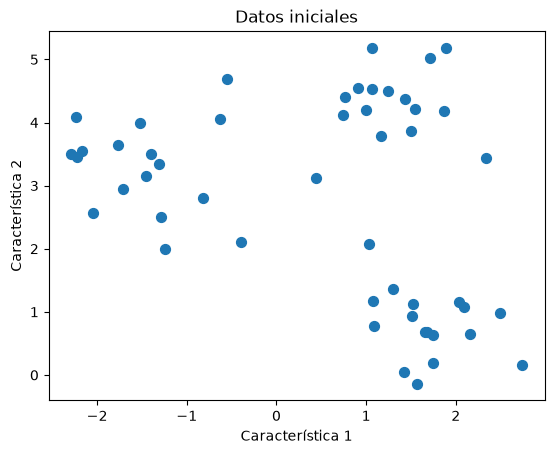

In [1]:
# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs

# Generación de datos simples para el clustering
np.random.seed(42)
X, y = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0) #Esta función genera puntos aleatorios pero siempre los mismos

# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Explicación:
# Hemos generado un dataset simple de 50 puntos con 3 centros.
# Los puntos están dispersos en un espacio bidimensional.



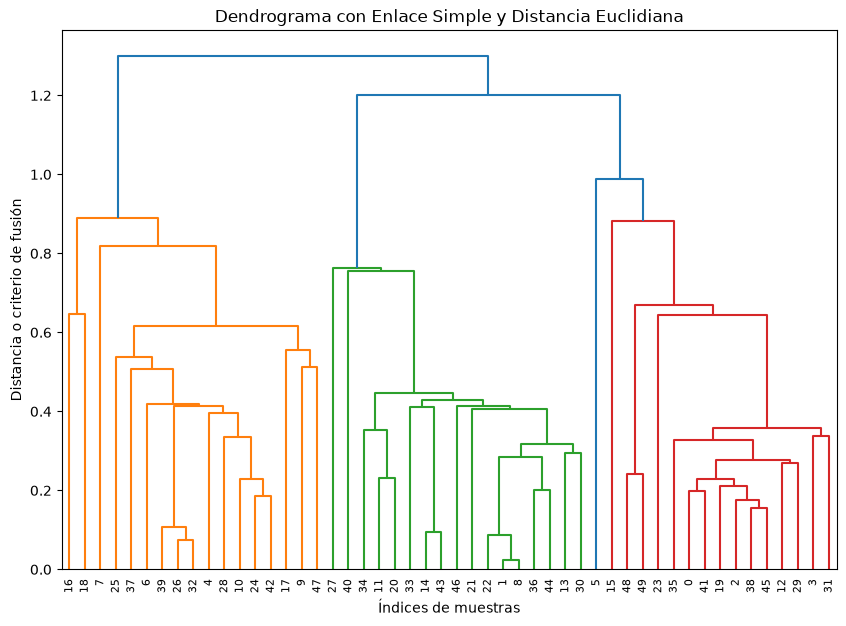

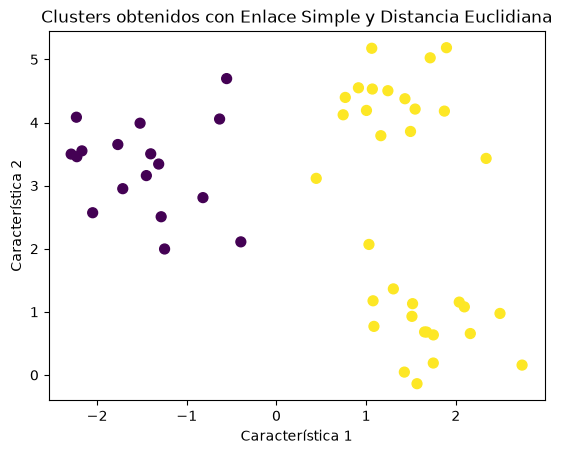

In [2]:
# Enlace simple (Single Linkage) con distancia euclidiana
Z = linkage(X, method='single', metric='euclidean')

# Dendrograma
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrograma con Enlace Simple y Distancia Euclidiana')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia o criterio de fusión')
plt.show()

# Definimos un umbral para cortar el dendrograma y obtener clusters
# El criterio 'maxclust' asegura obtener 3 clusters
clusters = fcluster(Z, t=2, criterion='maxclust')

# Visualización de los puntos coloreados según los clusters
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)  # 'viridis' da colores únicos a cada cluster
plt.title('Clusters obtenidos con Enlace Simple y Distancia Euclidiana')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Explicación de la visualización:
# Se ha hecho un corte en el dendrograma para obtener 3 clusters.
# Cada punto en el gráfico está coloreado según el cluster al que pertenece.


In [3]:
import pandas as pd
pd.DataFrame({"X":X[:,0], "Y":X[:,1], "Etiqueta":clusters})

,X,Y,Etiqueta
0,1.546323,4.212973,2
1,1.674674,0.680019,2
2,1.242588,4.503992,2
3,1.164111,3.791330,2
4,-1.768810,3.651349,1
5,0.443599,3.115309,2
6,-1.520604,3.989405,1
7,-0.397014,2.109227,1
8,1.651791,0.681932,2
9,-1.285499,2.506996,1


Dendrograma: Visualizamos el dendrograma para observar cómo se agrupan los puntos.

Corte en el dendrograma: Usamos la función fcluster para hacer un corte y asignar cada punto a un cluster.

Visualización de clusters: Los puntos del gráfico se colorean según el cluster al que pertenecen.

# Parte 2 - Variando el número de clusters con Enlace Simple y Distancia Euclidiana

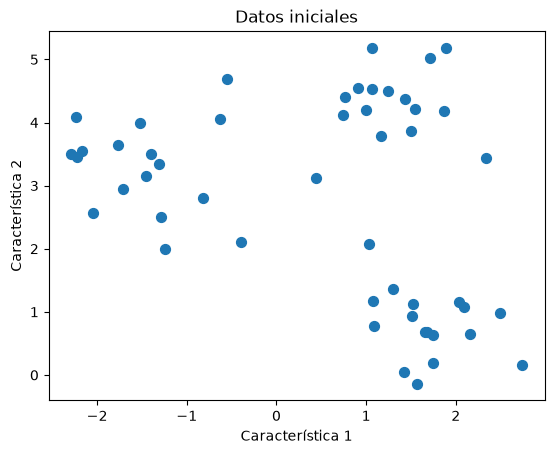

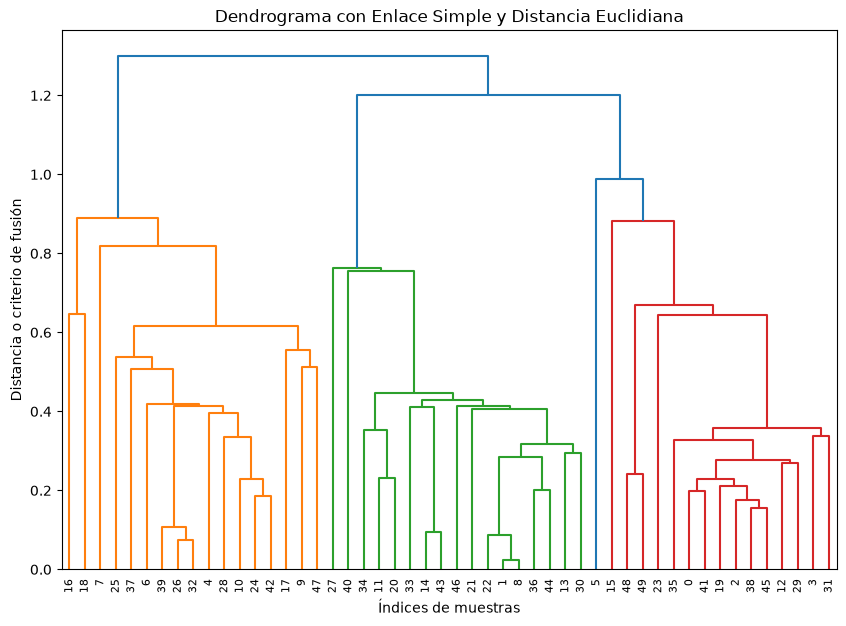

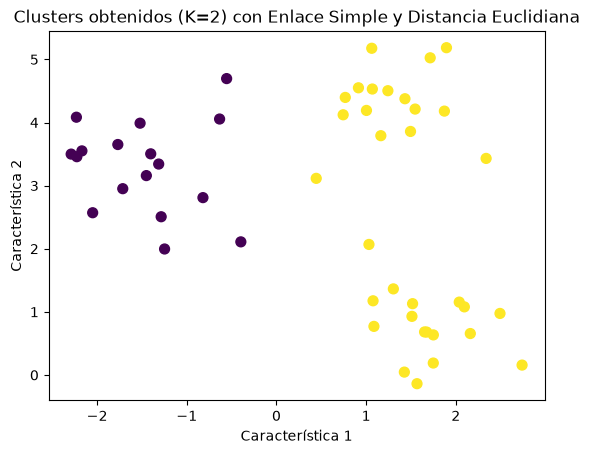

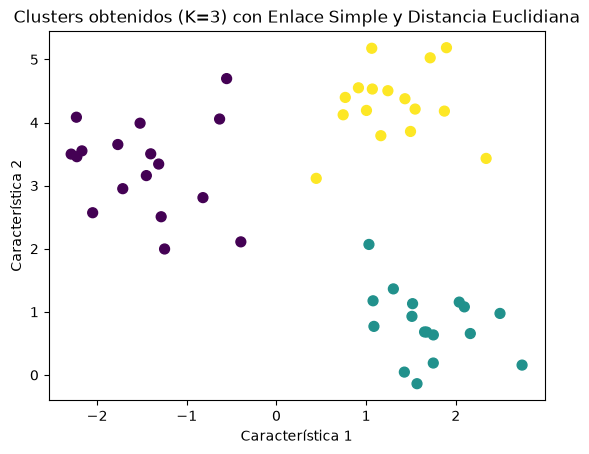

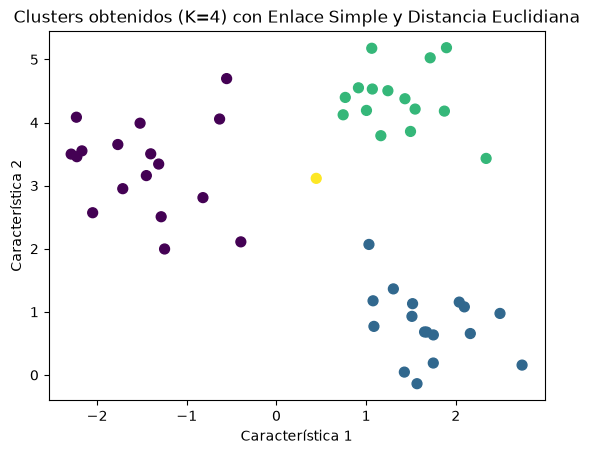

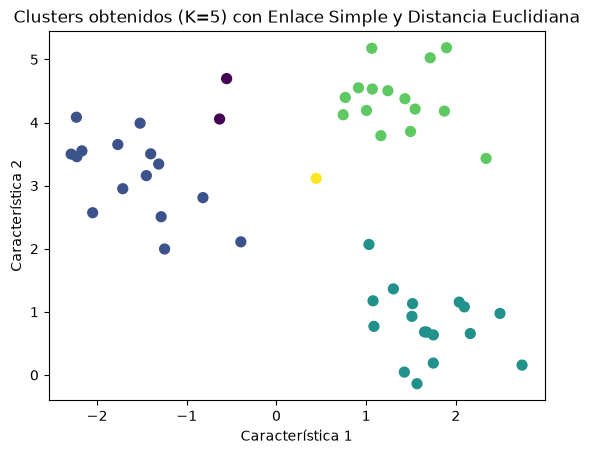

In [4]:
# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Enlace simple (Single Linkage) con distancia euclidiana
Z = linkage(X, method='single', metric='euclidean')

# Dendrograma
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrograma con Enlace Simple y Distancia Euclidiana')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia o criterio de fusión')
plt.show()

# Vamos a variar el número de clusters y visualizar los resultados
for num_clusters in [2, 3, 4, 5]:
    # Definimos un umbral para obtener num_clusters clusters
    clusters = fcluster(Z, t=num_clusters, criterion='maxclust')

    # Visualización de los puntos coloreados según los clusters
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
    plt.title(f'Clusters obtenidos (K={num_clusters}) con Enlace Simple y Distancia Euclidiana')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.show()

# Explicación:
# En este paso, hemos variado el número de clusters (K) entre 2, 3, 4 y 5.
# Para cada valor de K, hemos generado una visualización con los puntos agrupados en sus respectivos clusters.


Número de clusters variable: Se ha modificado el número de clusters entre 2 y 5, y visualizamos cómo los puntos se agrupan según el valor de K.

Dendrograma: Sigue siendo útil para observar las uniones, pero ahora cortamos el dendrograma a diferentes niveles para obtener más o menos clusters.

# Parte 3 - Variación de métodos de agrupamiento con Distancia Euclidiana

En esta parte, vamos a variar los métodos de agrupamiento, manteniendo la distancia euclidiana. Probaremos los diferentes métodos de enlace: completo, promedio, centroide y Ward, y observaremos cómo cambia el agrupamiento.

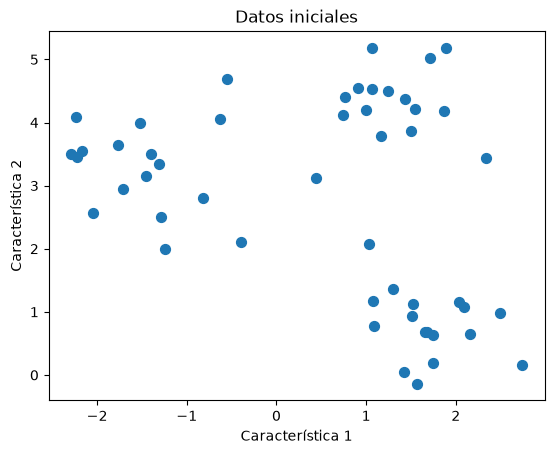

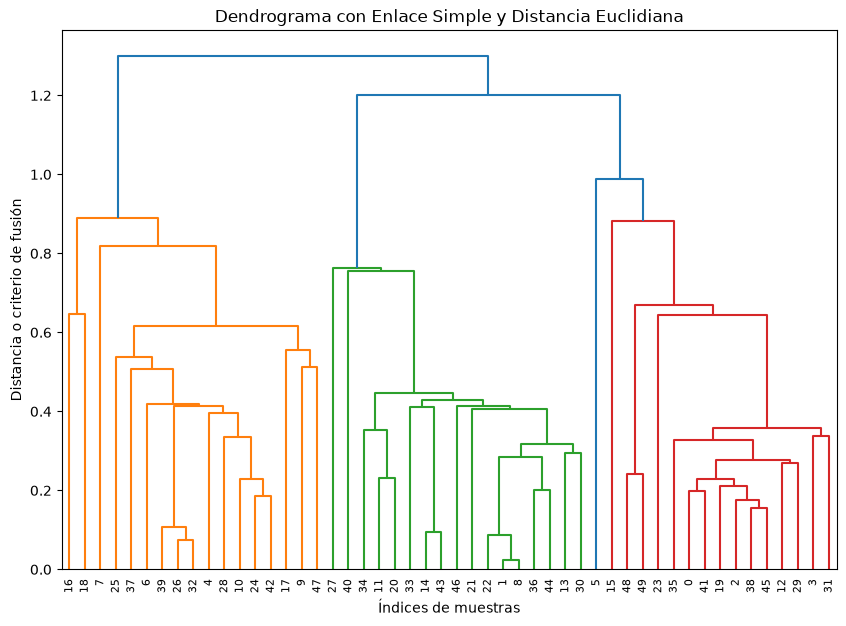

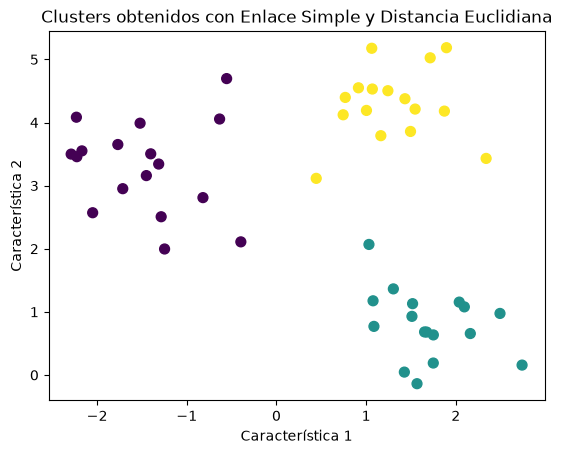

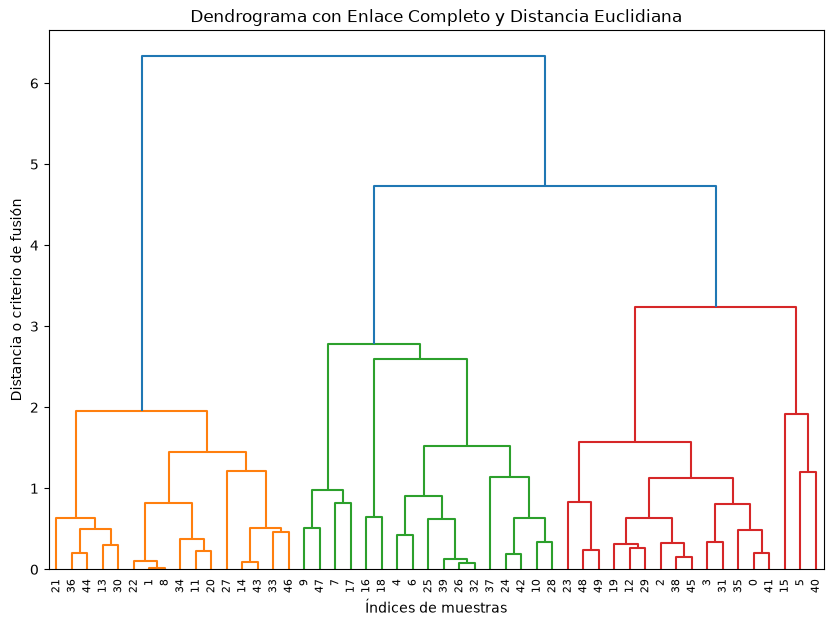

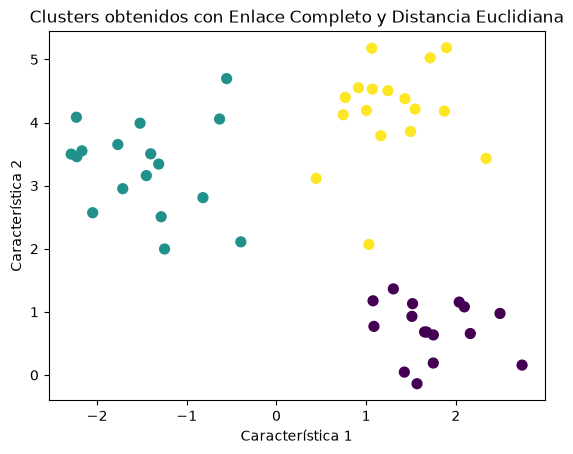

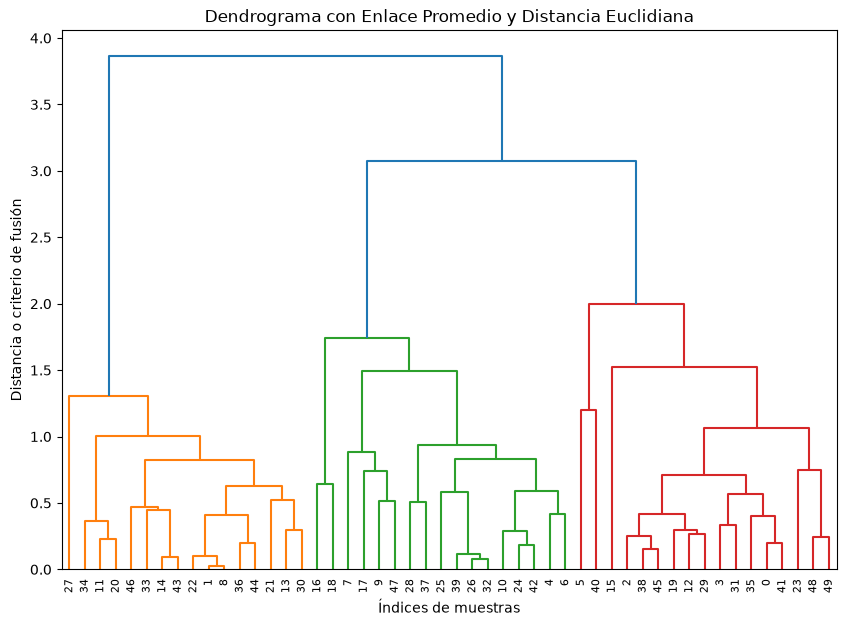

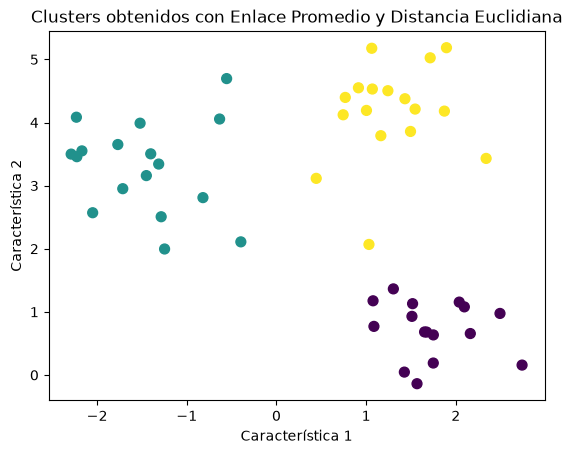

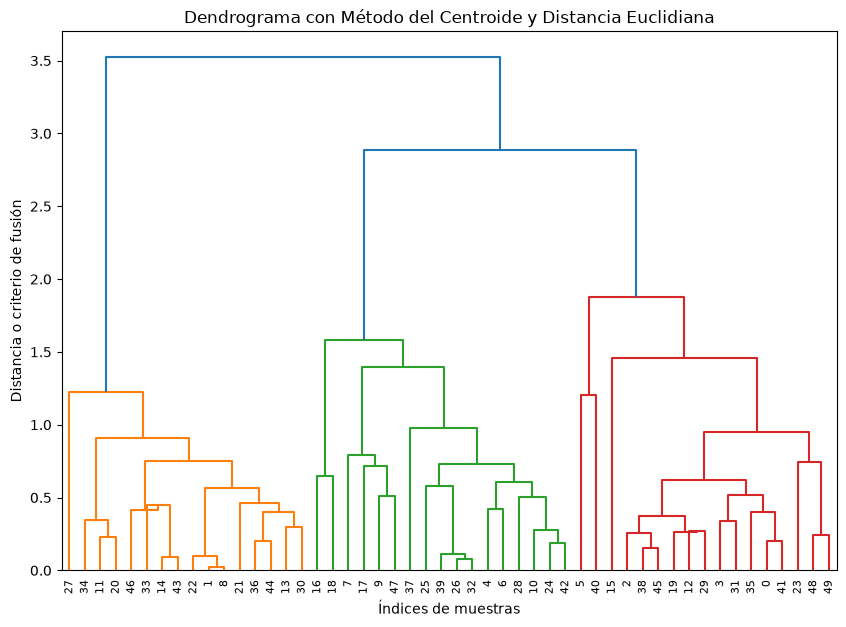

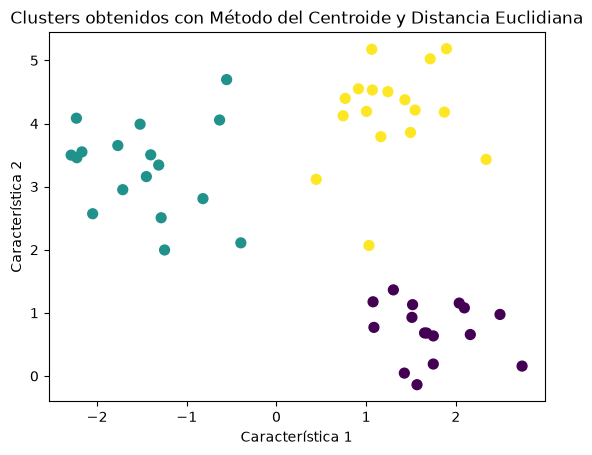

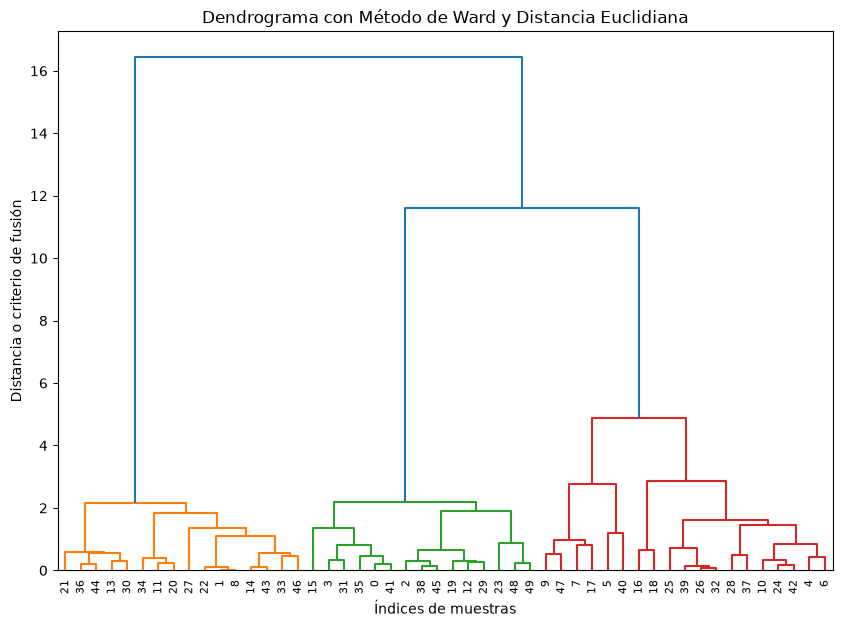

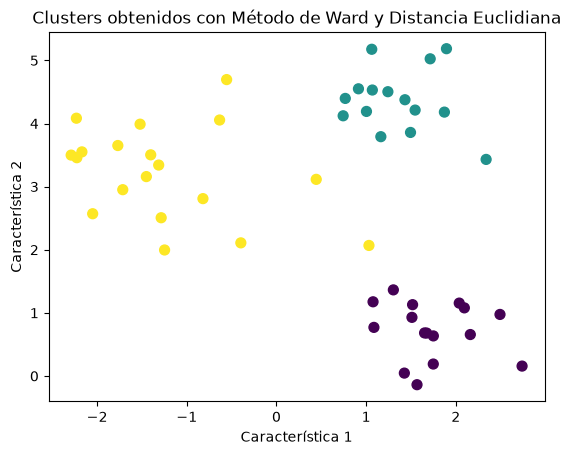

In [5]:
# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Definimos los métodos de agrupamiento a probar
methods = ['single', 'complete', 'average', 'centroid', 'ward']
method_names = ['Enlace Simple', 'Enlace Completo', 'Enlace Promedio', 'Método del Centroide', 'Método de Ward']

# Iteramos sobre cada método de agrupamiento y visualizamos los resultados
for method, method_name in zip(methods, method_names):
    Z = linkage(X, method=method, metric='euclidean')  # Aplicamos cada método con distancia euclidiana

    # Dendrograma para el método actual
    plt.figure(figsize=(10, 7))
    dendrogram(Z)
    plt.title(f'Dendrograma con {method_name} y Distancia Euclidiana')
    plt.xlabel('Índices de muestras')
    plt.ylabel('Distancia o criterio de fusión')
    plt.show()

    # Asignamos clusters (usando 3 clusters como ejemplo)
    clusters = fcluster(Z, t=3, criterion='maxclust')

    # Visualización de los puntos coloreados según los clusters
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
    plt.title(f'Clusters obtenidos con {method_name} y Distancia Euclidiana')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.show()

Métodos de agrupamiento: En esta parte, hemos probado distintos métodos de enlace:

* Enlace Simple (Single Linkage): Agrupa puntos según la menor distancia entre clusters.

* Enlace Completo (Complete Linkage): Agrupa según la mayor distancia entre clusters.

* Enlace Promedio (Average Linkage): Considera la distancia promedio entre todos los puntos en los clusters.

* Método del Centroide: Agrupa utilizando la media de los puntos de los clusters.
* Método de Ward: Minimiza la varianza total dentro de los clusters.

Visualizaciones: Para cada método, visualizamos tanto el dendrograma como la agrupación resultante con 3 clusters.

# Parte 4 - Variación de las métricas de distancia

Ahora continuamos, donde variamos las métricas de distancia. Vamos a comparar los resultados utilizando distancia Euclidiana y distancia Manhattan en conjunto con los métodos de enlace que ya vimos. Esto permitirá observar cómo la métrica de distancia afecta el agrupamiento.

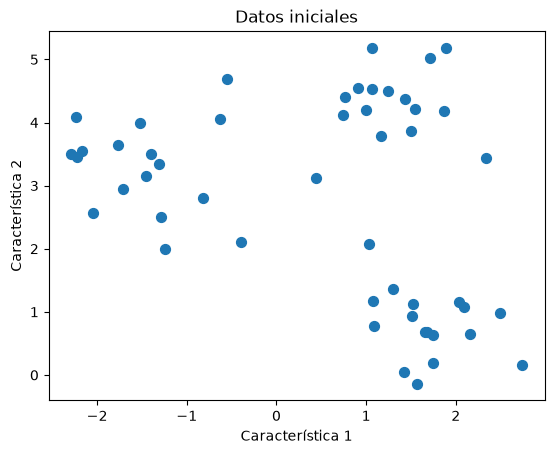

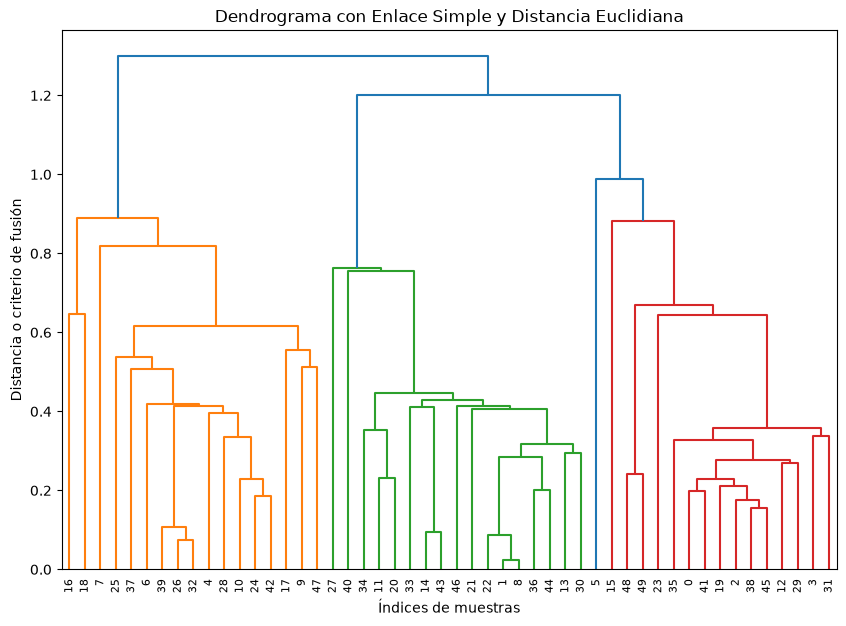

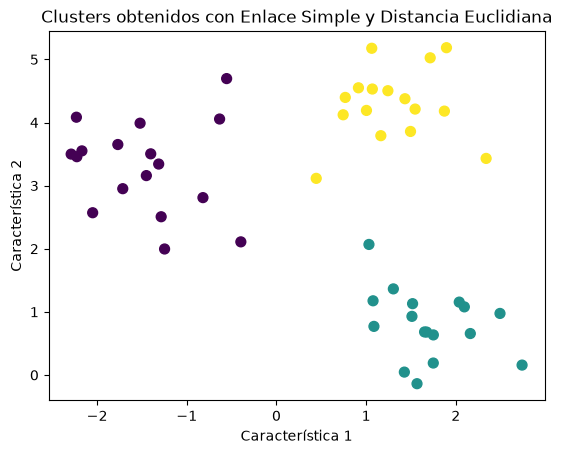

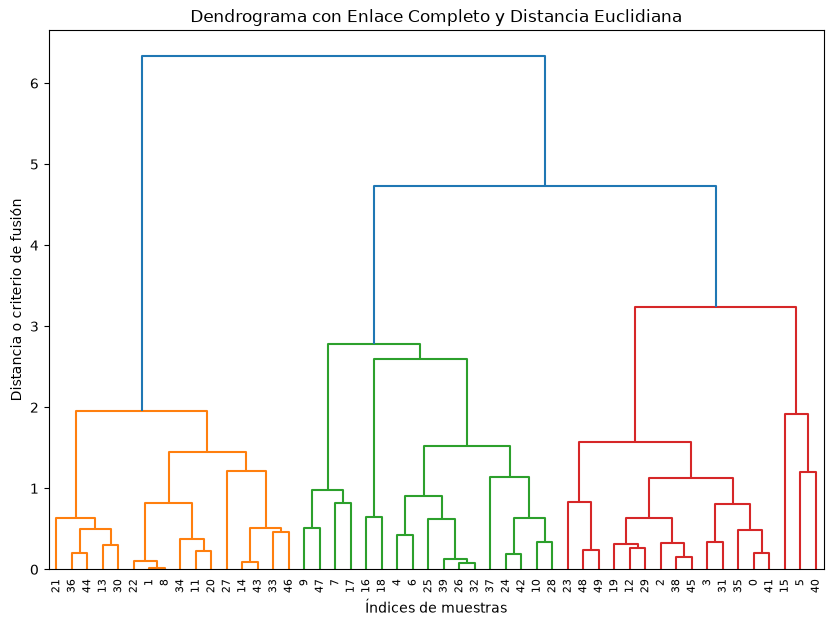

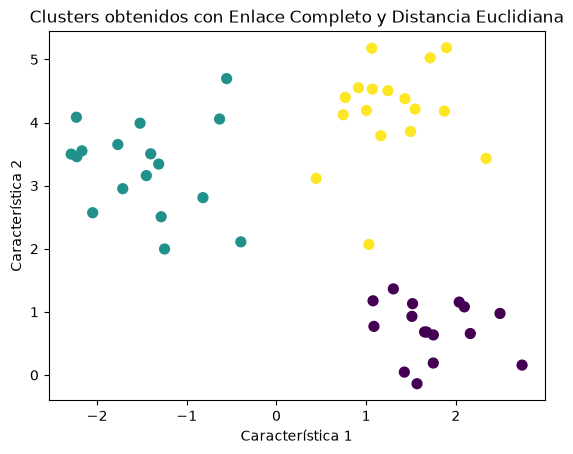

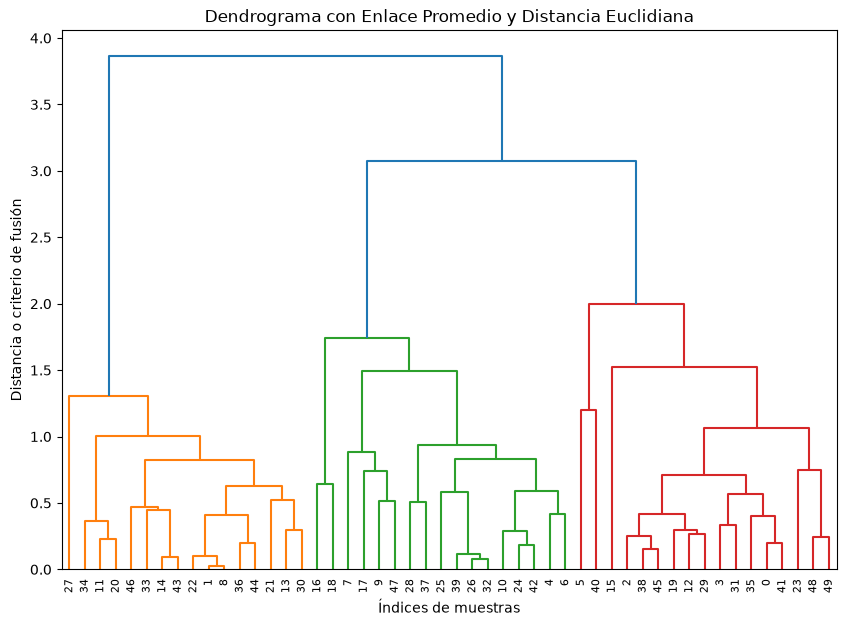

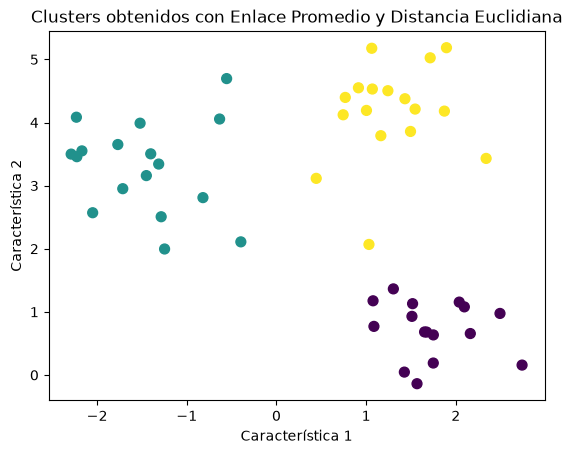

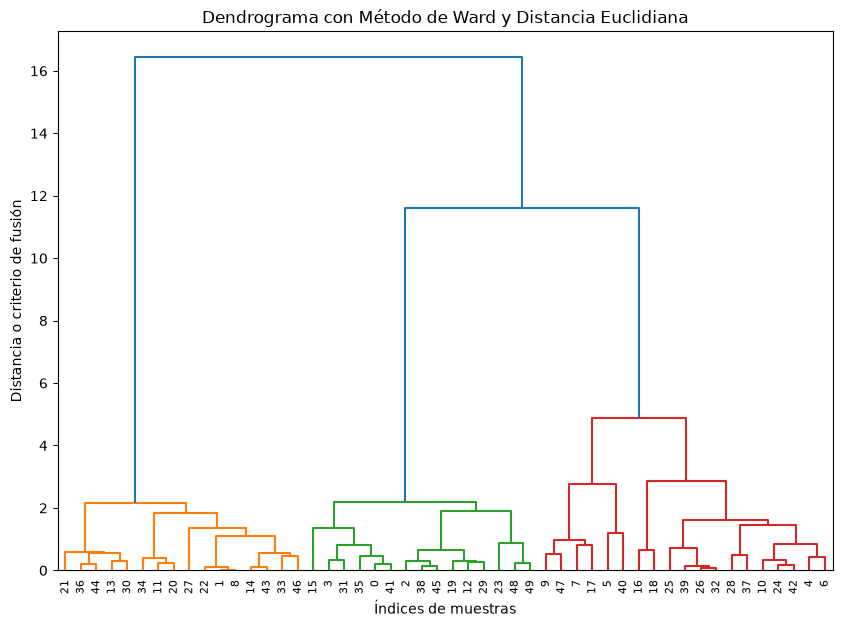

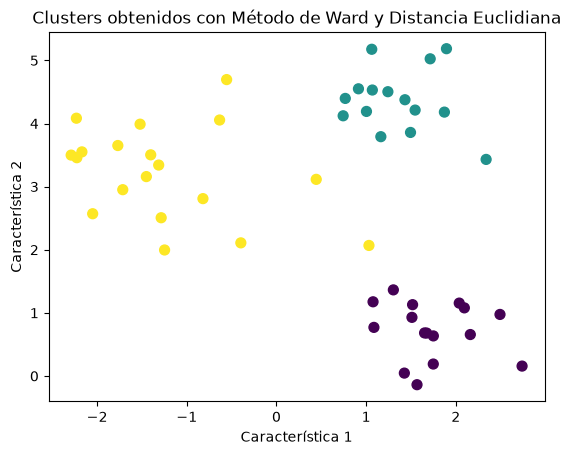

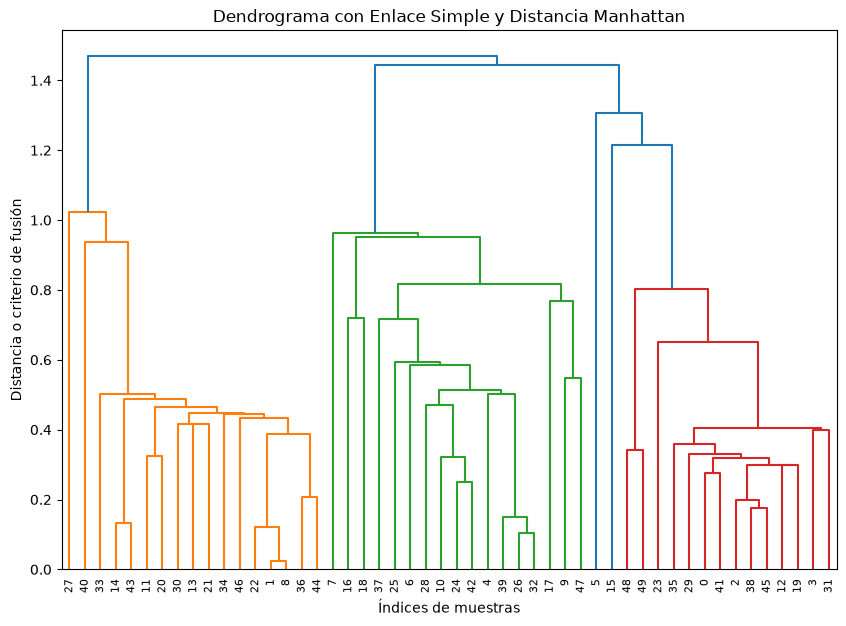

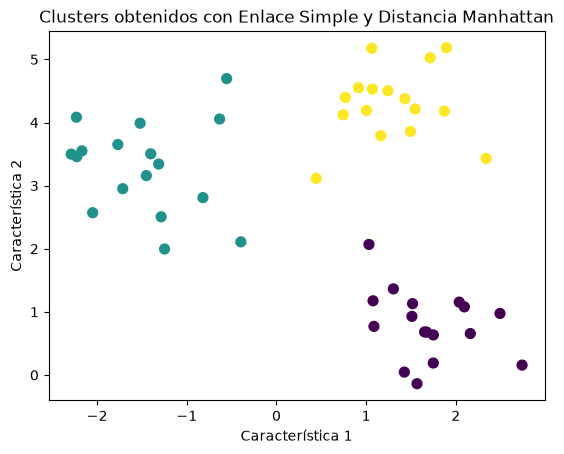

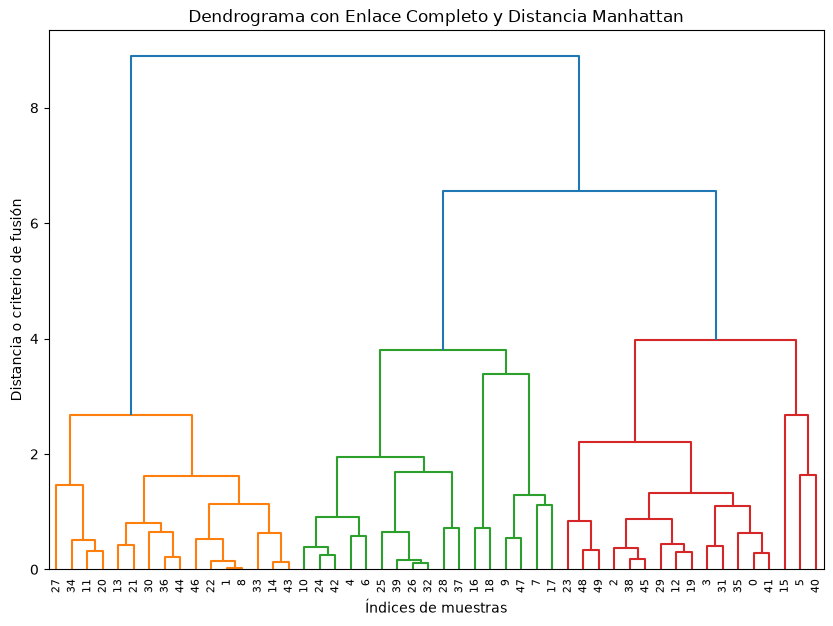

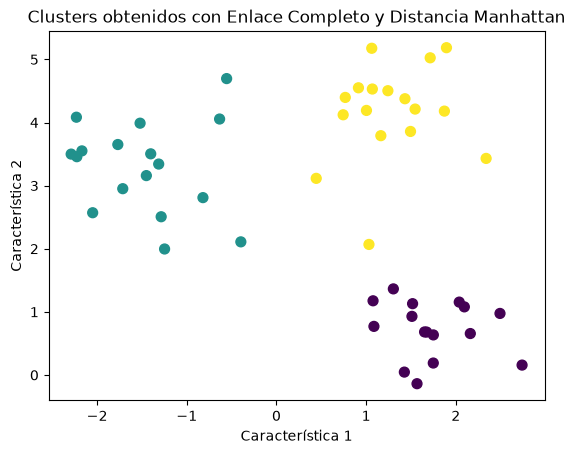

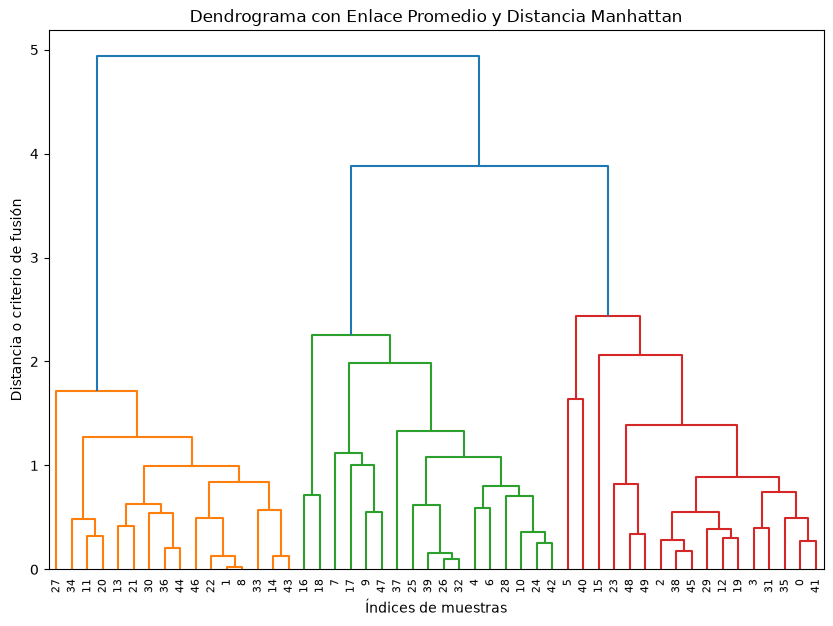

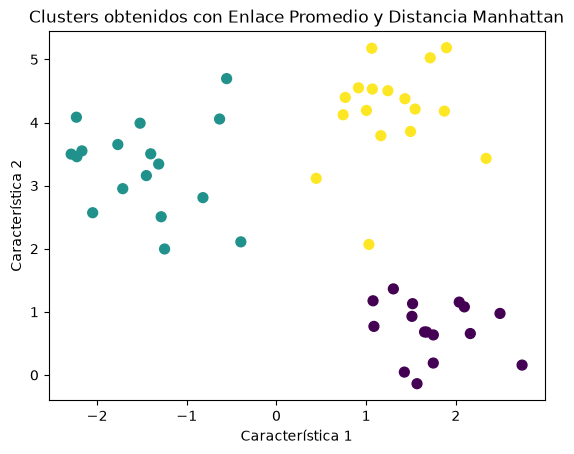

In [6]:
# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Definimos las combinaciones de métodos de agrupamiento y distancias a probar
methods = ['single', 'complete', 'average', 'ward']
distances = ['euclidean', 'cityblock']  # cityblock es la distancia Manhattan
method_names = ['Enlace Simple', 'Enlace Completo', 'Enlace Promedio', 'Método de Ward']
distance_names = ['Distancia Euclidiana', 'Distancia Manhattan']

# Iteramos sobre cada combinación de método de agrupamiento y métrica de distancia
for distance, distance_name in zip(distances, distance_names):
    for method, method_name in zip(methods, method_names):
        # Excluir método Ward si la distancia no es Euclidiana
        if method == 'ward' and distance != 'euclidean':
            continue

        Z = linkage(X, method=method, metric=distance)  # Aplicamos cada método con la distancia seleccionada

        # Dendrograma para el método y la distancia actuales
        plt.figure(figsize=(10, 7))
        dendrogram(Z)
        plt.title(f'Dendrograma con {method_name} y {distance_name}')
        plt.xlabel('Índices de muestras')
        plt.ylabel('Distancia o criterio de fusión')
        plt.show()

        # Asignamos clusters (usando 3 clusters como ejemplo)
        clusters = fcluster(Z, t=3, criterion='maxclust')

        # Visualización de los puntos coloreados según los clusters
        plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
        plt.title(f'Clusters obtenidos con {method_name} y {distance_name}')
        plt.xlabel('Característica 1')
        plt.ylabel('Característica 2')
        plt.show()

Explicación:
Métricas de distancia:

* Distancia Euclidiana: La distancia ordinaria entre puntos (geométrica).
* Distancia Manhattan (cityblock): Suma de las distancias absolutas entre las coordenadas (como si siguieras las calles de una cuadrícula).

Métodos de agrupamiento: Reutilizamos los métodos de enlace simple, completo, promedio y Ward.

Visualizaciones: Comparamos cómo las diferentes métricas de distancia afectan el dendrograma y los clusters formados.